# Phase 1 — Building a universe you can trust

**Project:** statistical arbitrage on S&P 500 utilities, 2014-2026.

This notebook tells the story of Phase 1 in the order it actually happened: the decisions, what
we found along the way, and **the two times we were wrong**.

Phase 1 produces no signal and no P&L. It produces a universe of securities and a price series.
That is why it looks innocuous — and exactly why it is dangerous: **a mistake made here never
raises an error.** It produces a backtest that runs, reports a Sharpe ratio, and is wrong.

| Section | What it shows |
|---|---|
| 1 | Why a "current constituents" universe is a leak |
| 2 | Point-in-time reconstruction |
| 3 | PG&E: what point-in-time catches on its own |
| 4 | **Ticker recycling** — the bug that would have invalidated everything |
| 5 | **Forward-fill: a belief tested, then refuted** |
| 6 | Dividends: why total-return prices |
| 7 | Residual survivorship, quantified and signed |

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from src import config as C
from src.universe import validate_identity, tradable_universe, membership_windows

np.random.seed(C.SEED)          # reproducibility: the seed is fixed in src/config.py

# Validated categorical palette (separation guaranteed for normal and colour-blind vision)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA, VIOLET, RED = "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#16191d", "#5b6470", "#dfe3e8"

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 9.5,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.bottom": True, "ytick.left": False,
    "grid.color": GRID, "grid.linewidth": .8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10, "lines.linewidth": 2,
})

memb  = pd.read_parquet(C.DATA_PROC / "membership_utilities.parquet")
close = pd.read_parquet(C.DATA_PROC / "prices_adj.parquet")
val   = validate_identity(memb, close)
trad  = tradable_universe(memb, close)

print(f"index snapshots : {memb.shape[0]}   ticker union : {memb.shape[1]}")
print(f"trading sessions: {len(close)}   ({close.index[0]:%d/%m/%Y} -> {close.index[-1]:%d/%m/%Y})")

index snapshots : 25   ticker union : 38
trading sessions: 3140   (02/01/2014 -> 29/06/2026)


---
## 1. The problem: "take the current constituents" is a leak

The method used in almost every student project: pull the current S&P 500 membership list, filter
on sector, download history. It is wrong.

Selecting today the companies in the index means using information dated today — **the fact that
these companies still exist and are large enough to be in it** — to decide what to trade in 2015.
That is structurally identical to look-ahead on the signal. The only difference: the leaking
variable is not a future price, it is **survival**.

And the effect always runs the same way: you exclude exactly the companies that went bankrupt,
were acquired, or fell apart — the cases where cointegration breaks violently.

Let us measure the gap between the two universes.

In [2]:
current = set(memb.columns[memb.iloc[-1]])            # members at the last snapshot (2026-01)
gone    = set(memb.columns[memb.any()]) - current      # members at some point, not today

print(f"'current constituents' universe   : {len(current)} tickers")
print(f"'ever belonged to sector' universe: {int(memb.any().sum())} tickers")
print(f"invisible to the naive method     : {len(gone)}  ->  {sorted(gone)}")

# how many names would the naive method trade BEFORE they entered the index?
w = membership_windows(memb)
early = w[(w.memb_first > memb.index[0]) & (w.index.isin(current))]
print(f"\nnames the naive method would trade BEFORE index entry: {len(early)}")
print(early[["memb_first"]].assign(
    entered=lambda d: d.memb_first.dt.strftime("%Y-%m")).drop(columns="memb_first").to_string())

'current constituents' universe   : 31 tickers
'ever belonged to sector' universe: 38 tickers
invisible to the naive method     : 7  ->  ['GAS', 'NU', 'OKE', 'POM', 'SCG', 'TE', 'TEG']

names the naive method would trade BEFORE index entry: 7
        entered
ticker         
ATO     2019-07
AWK     2016-07
CEG     2022-07
ES      2015-07
EVRG    2018-07
LNT     2017-01
VST     2024-07


Two distinct leaks, then. The naive method **excludes** 7 names that genuinely belonged to the
sector (survivorship), and **includes** 7 others *before they entered the index* — that is, at a
time when they were too small or too illiquid to be traded the way the backtest assumes.

---
## 2. Point-in-time reconstruction

**The principle.** The Wikipedia page listing S&P 500 constituents has been continuously edited
for more than fifteen years, and **every past version remains accessible**. So we retrieve the
page *as it existed* on each selection date. That gives us membership **and** the GICS sector as
observed at the time — including for companies that have since disappeared.

**The detail that guarantees no leak** is one parameter:

```python
params = {"rvstart": selection_date,
          "rvdir":   "older",   # <-- walk BACK in time from that date
          "rvlimit": 1}
```

`rvdir="older"` asks for the last revision published **before** the selection date. With
`"newer"` you would get the first revision published *after* — a page that may already reflect
index changes later than the decision. **One word separates a correct reconstruction from a leak.**

**Semi-annual cadence**: since walk-forward re-selection is annual, each selection date has a
snapshot at most 6 months old. Going monthly would multiply requests sixfold for precision the
strategy cannot use.

In [3]:
import json
meta = json.loads((C.DATA_PROC / "membership_utilities_meta.json").read_text())
lag = pd.Series([m["lag_days"] for m in meta])
print("gap between selection date and the revision used:")
print(f"  median {lag.median():.0f} d | max {lag.max()} d | always >= 0 : {bool((lag>=0).all())}")
print("\nThe gap is always positive: the page used LAGS reality, never leads it.")
print("The direction of the error is therefore conservative.")

gap between selection date and the revision used:
  median 2 d | max 19 d | always >= 0 : True

The gap is always positive: the page used LAGS reality, never leads it.
The direction of the error is therefore conservative.


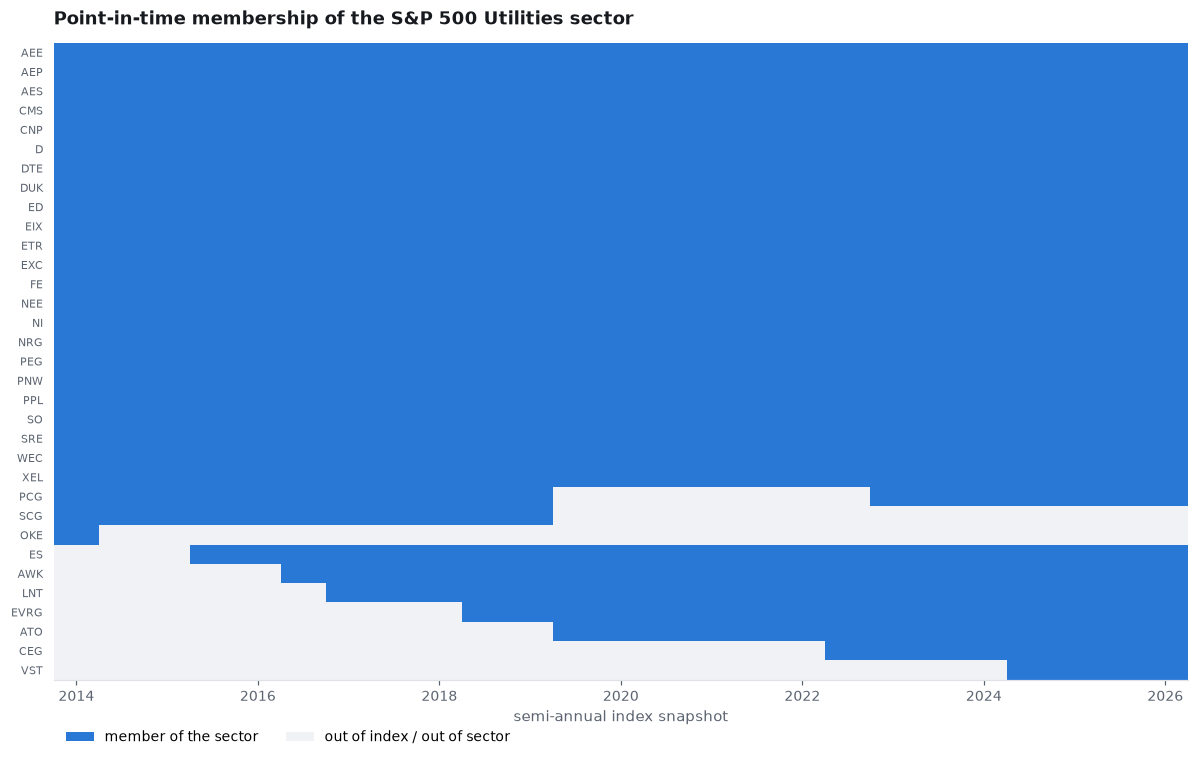

In [4]:
order = list(trad.columns[trad.any()])
order.sort(key=lambda t: (trad[t].values.argmax(), -trad[t].sum()))
mat = trad[order].T.astype(int).values

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(mat, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap(["#f0f2f5", BLUE]),
          interpolation="nearest", vmin=0, vmax=1)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7.5)
xt = range(0, len(trad.index), 4)
ax.set_xticks(list(xt)); ax.set_xticklabels([f"{trad.index[i]:%Y}" for i in xt])
ax.set_title("Point-in-time membership of the S&P 500 Utilities sector")
ax.grid(False); ax.set_xlabel("semi-annual index snapshot")
ax.legend(handles=[Patch(facecolor=BLUE, label="member of the sector"),
                   Patch(facecolor="#f0f2f5", label="out of index / out of sector")],
          loc="upper left", bbox_to_anchor=(0, -.06), ncol=2)
plt.tight_layout(); plt.show()

The matrix is not full. Entries appear as a staircase on the right (ATO in 2019, CEG in 2022,
VST in 2024), and **one row has a hole in the middle**. That is the interesting one.

---
## 3. PG&E: what point-in-time catches without being asked

`PCG` (PG&E) is **out of the index from July 2019 to July 2022**: Chapter 11 in January 2019
after the California wildfires, removal from the S&P 500, then readmission after emerging.

Since PCG is a member **today**, a universe built on current constituents would include it
throughout — and would therefore trade it **during its bankruptcy**, implicitly knowing it came
out alive.

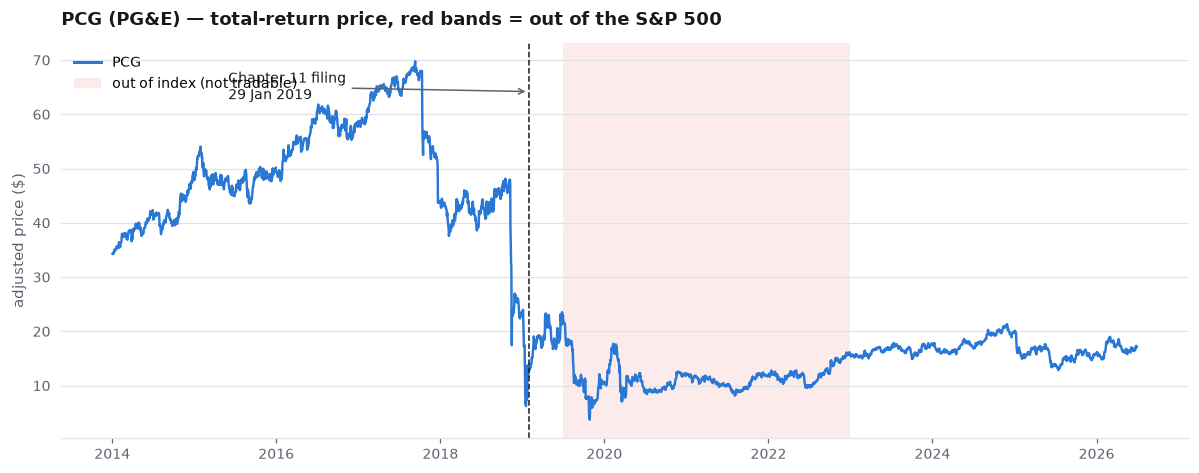

drawdown from 1 Nov 2017 to the filing : -75.6 %
rebound from Jul 2020 to Jul 2022      : +13.4 %


In [5]:
pcg = close["PCG"].dropna()
inx = trad["PCG"]
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(pcg.index, pcg.values, color=BLUE, lw=1.6)

# out-of-index spans, inferred from the semi-annual snapshots
out = inx[~inx]
for d in out.index:
    ax.axvspan(d, d + pd.DateOffset(months=6), color="#e34948", alpha=.11, lw=0)
ax.axvline(pd.Timestamp("2019-01-29"), color=INK, lw=1, ls="--")
ax.annotate("Chapter 11 filing\n29 Jan 2019", xy=(pd.Timestamp("2019-01-29"), pcg.max()*.92),
            xytext=(pd.Timestamp("2015-06-01"), pcg.max()*.90), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.set_title("PCG (PG&E) — total-return price, red bands = out of the S&P 500")
ax.set_ylabel("adjusted price ($)")
ax.legend(handles=[plt.Line2D([], [], color=BLUE, lw=2, label="PCG"),
                   Patch(facecolor="#e34948", alpha=.11, label="out of index (not tradable)")],
          loc="upper left")
plt.tight_layout(); plt.show()

fall = pcg.loc["2017-11-01":"2019-01-29"]
print(f"drawdown from 1 Nov 2017 to the filing : {100*(fall.iloc[-1]/fall.iloc[0]-1):.1f} %")
reb = pcg.loc["2020-07-01":"2022-07-01"]
print(f"rebound from Jul 2020 to Jul 2022      : {100*(reb.iloc[-1]/reb.iloc[0]-1):+.1f} %")

A naive strategy would have sat through the collapse **and** collected the rebound, never asking
whether the stock was borrowable during the proceedings. Point-in-time reconstruction excludes it
automatically — with no PG&E-specific rule written anywhere. We fixed the cause, not the symptom.

---
## 4. The bug that would have invalidated everything: ticker recycling

Once the point-in-time universe was built, we downloaded prices for the 38 tickers. Looking at
the start dates, we hit this:

In [6]:
sus = val[val.status != "OK"].copy()
print(sus[["memb_first", "memb_last", "px_first", "px_last", "overlap_frac", "status"]]
      .to_string(formatters={
          "memb_first": lambda d: f"{d:%Y-%m}", "memb_last": lambda d: f"{d:%Y-%m}",
          "px_first": lambda d: f"{d:%Y-%m-%d}" if pd.notna(d) else "     -",
          "px_last":  lambda d: f"{d:%Y-%m-%d}" if pd.notna(d) else "     -"}))

       memb_first memb_last   px_first    px_last  overlap_frac    status
ticker                                                                   
GAS       2014-01   2016-07          -          -         0.000   NO_DATA
NU        2014-01   2015-01 2021-12-09 2026-06-29         0.000  RECYCLED
POM       2014-01   2016-01 2025-10-08 2026-06-29         0.000  RECYCLED
TE        2014-01   2016-07 2020-01-10 2026-06-29         0.000  RECYCLED
TEG       2014-01   2015-07 2015-12-22 2022-03-02         0.014  RECYCLED


`NU` belonged to the sector in **2014-2015**. The vendor serves prices starting **9 December 2021**.

That is not Northeast Utilities. It is **Nu Holdings**, the Brazilian neobank, which took over the
ticker after its late-2021 IPO. Same story for `POM` (Pepco, acquired 2016 — data from 2025),
`TE` (TECO, acquired 2016 — data from 2020) and `TEG` (Integrys, acquired 2015).

**Tickers are not durable identifiers.** When a company disappears, its symbol returns to the
pool. Three letters do not identify a company: they identify a slot on a market at a point in time.

The chart below makes the problem visible at a glance.

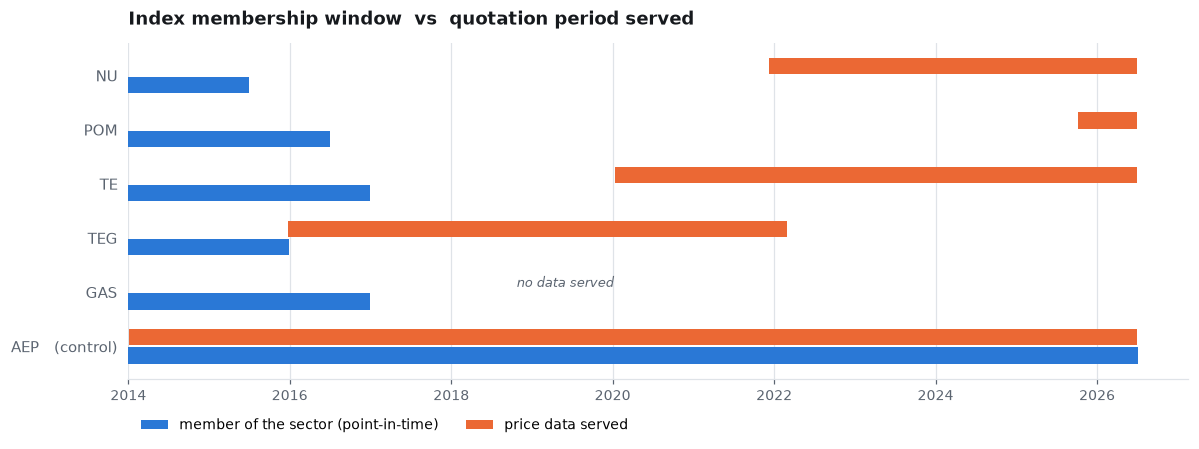

In [7]:
show = ["NU", "POM", "TE", "TEG", "GAS", "AEP"]     # AEP = healthy control
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, t in enumerate(show):
    r = val.loc[t]
    ax.barh(i + .17, (r.memb_last - r.memb_first).days + 183, left=r.memb_first,
            height=.30, color=BLUE, zorder=3)
    if pd.notna(r.px_first):
        ax.barh(i - .17, (r.px_last - r.px_first).days, left=r.px_first,
                height=.30, color=ORANGE, zorder=3)
    else:
        ax.text(pd.Timestamp("2019-06-01"), i - .17, "no data served",
                va="center", ha="center", fontsize=8.5, color=MUTED, style="italic")
ax.set_yticks(range(len(show)))
ax.set_yticklabels([f"{t}" + ("   (control)" if t == "AEP" else "") for t in show], fontsize=10)
ax.invert_yaxis(); ax.grid(False); ax.xaxis.grid(True)
ax.set_title("Index membership window  vs  quotation period served")
ax.legend(handles=[Patch(facecolor=BLUE, label="member of the sector (point-in-time)"),
                   Patch(facecolor=ORANGE, label="price data served")],
          loc="upper left", bbox_to_anchor=(0, -.08), ncol=2)
plt.tight_layout(); plt.show()

For `AEP` the two bars overlap: the ticker denotes the same company throughout.
For `NU`, `POM` and `TE`, **the two bars do not even touch**.

### The detection rule

We hold two independent pieces of information: the membership window (point-in-time
reconstruction) and the quotation period (price vendor). If the ticker denotes the same company
in both sources, **the two intervals must overlap**.

$$\text{overlap} = \frac{\big|\,[\text{first quote},\ \text{last quote}]\ \cap\ [\text{index entry},\ \text{index exit}]\,\big|}{\big|\,[\text{index entry},\ \text{index exit}]\,\big|}$$

The check is **blocking**, not advisory: suspect tickers leave the universe.

### What would have happened without it

The backtest would have tested cointegration between **Nu Holdings** and Duke Energy, possibly
found it significant, and opened positions. No exception raised, no test failed, a perfectly
smooth P&L curve. **The mistakes that matter do not raise errors.**

### Two bugs in the check itself

Even an anti-error check must be verified. The first two versions were wrong:

1. **ONEOK false positive.** `OKE` was flagged as recycled. It appears in only **one** snapshot
   (GICS reclassified it from *Utilities* to *Energy* in early 2014), so its window had zero
   length and the overlap divided by zero. Fix: being a member at date $t$ means being one at
   least until the next snapshot — the window is widened by 6 months.
2. **Exact-zero threshold.** The rule flagged as recycled an overlap of *exactly* zero. `TEG`
   has an overlap of **0.014**: Integrys was acquired in June 2015 and the ticker reassigned by
   December, so the intervals overlap by ten days. Fix: threshold at 5 %. A binary test resting
   on exact equality is fragile.

### The blind spot that remains

The rule compares two intervals; it would poorly detect a recycling occurring **during** the
membership window. A genuinely robust check would use a durable identifier (CUSIP, SEDOL,
PERMNO) — precisely what professional databases sell.

---
## 5. Forward-fill: a belief tested, then refuted

When a series has a gap, the universal reflex is *forward-fill*. We do not use it — but the
reason is **not** the one you read everywhere, and this section recounts a mistake we made before
testing it.

### The usual argument

"Carrying a price forward creates a zero return followed by a catch-up, hence *no move, then
compensating move*: the signature of mean reversion. Forward-fill therefore manufactures the very
signal we are looking for."

That is what we had written. **Let us test it**: simulate a **pure** random walk, hence no mean
reversion at all. If the argument holds, forward-fill should make the ADF test reject more often
than it should.

In [8]:
from statsmodels.tsa.stattools import adfuller
rng = np.random.default_rng(C.SEED)

def forward_fill(x, gaps):
    idx = np.arange(len(x))
    return x[np.maximum.accumulate(np.where(gaps, 0, idx))]

rej_t, rej_f, ac_t, ac_f = [], [], [], []
for _ in range(400):
    n = 750
    a, b = np.cumsum(rng.normal(0, .012, n)), np.cumsum(rng.normal(0, .012, n))
    s_true = a - b
    gaps = rng.random(n) < .05; gaps[0] = False
    s_ff = forward_fill(a, gaps) - b
    rej_t.append(adfuller(s_true, maxlag=1, regression="c")[1] < .05)
    rej_f.append(adfuller(s_ff,   maxlag=1, regression="c")[1] < .05)
    dt, df = np.diff(s_true), np.diff(s_ff)
    ac_t.append(np.corrcoef(dt[:-1], dt[1:])[0, 1])
    ac_f.append(np.corrcoef(df[:-1], df[1:])[0, 1])

print("PURE random walk (no mean reversion), 400 simulations, 5 % gaps\n")
print(f"  ADF rejection rate at 5 %  without ffill : {100*np.mean(rej_t):5.1f} %")
print(f"  ADF rejection rate at 5 %  with ffill    : {100*np.mean(rej_f):5.1f} %")
print(f"  lag-1 autocorr. of diffs   without ffill : {np.mean(ac_t):+.4f}")
print(f"  lag-1 autocorr. of diffs   with ffill    : {np.mean(ac_f):+.4f}")

PURE random walk (no mean reversion), 400 simulations, 5 % gaps

  ADF rejection rate at 5 %  without ffill :   6.8 %
  ADF rejection rate at 5 %  with ffill    :   6.5 %
  lag-1 autocorr. of diffs   without ffill : -0.0016
  lag-1 autocorr. of diffs   with ffill    : -0.0017


**No effect.** The argument is false.

The reason, once seen, is simple: forward-fill **redistributes** the increments without modifying
them. The missing day carries a zero return, the next day carries the sum of both increments. The
total is unchanged and, since increments are independent, the covariance between consecutive
returns stays zero. There is no "compensating catch-up": there is a deferral.

Now let us check on a genuinely mean-reverting spread (Ornstein-Uhlenbeck) and look for what
forward-fill *actually* breaks.

In [9]:
def ou_path(n, half_life=15, sigma=.01, rng=None):
    lam = np.log(2) / half_life
    s = np.zeros(n)
    for t in range(1, n):
        s[t] = s[t-1] * np.exp(-lam) + rng.normal(0, sigma)
    return s

def half_life_est(x):
    x = x[~np.isnan(x)]
    beta = np.polyfit(x[:-1], np.diff(x), 1)[0]
    return -np.log(2) / np.log(1 + beta) if -1 < beta < 0 else np.nan

def zscore(s, w=60):
    s = pd.Series(s)
    return ((s - s.rolling(w).mean()) / s.rolling(w).std()).values

rng = np.random.default_rng(C.SEED)
rows = []
for _ in range(300):
    n = 750
    s = ou_path(n, rng=rng)
    gaps = rng.random(n) < .05; gaps[0] = False
    s_ff = forward_fill(s, gaps)
    z_t, z_f = zscore(s), zscore(s_ff)
    ent_f = np.abs(z_f) > 2
    rows.append(dict(hl_true=half_life_est(s), hl_ff=half_life_est(s_ff),
                     n_t=int((np.abs(z_t) > 2).sum()), n_f=int(ent_f.sum()),
                     stale=int((ent_f & gaps).sum())))
r = pd.DataFrame(rows)
r["frac_stale"] = r.stale / r.n_f.clip(lower=1)

print("OU spread (true half-life = 15 d), 5 % gaps, 300 simulations\n")
print(f"  estimated half-life  without ffill : {r.hl_true.mean():6.2f} d")
print(f"  estimated half-life  with ffill    : {r.hl_ff.mean():6.2f} d   "
      f"(bias {100*(r.hl_ff.mean()/r.hl_true.mean()-1):+.1f} %)")
print(f"  signals |z| > 2      without ffill : {r.n_t.mean():6.1f}")
print(f"  signals |z| > 2      with ffill    : {r.n_f.mean():6.1f}")
print(f"\n  >> signals landing on a NON-TRADING day : {r.stale.mean():.1f} per series")
print(f"  >> i.e. {100*r.frac_stale.mean():.1f} % of signals, at a price that never existed")

OU spread (true half-life = 15 d), 5 % gaps, 300 simulations

  estimated half-life  without ffill :  13.95 d
  estimated half-life  with ffill    :  13.98 d   (bias +0.2 %)
  signals |z| > 2      without ffill :   67.8
  signals |z| > 2      with ffill    :   67.6

  >> signals landing on a NON-TRADING day : 2.6 per series
  >> i.e. 3.8 % of signals, at a price that never existed


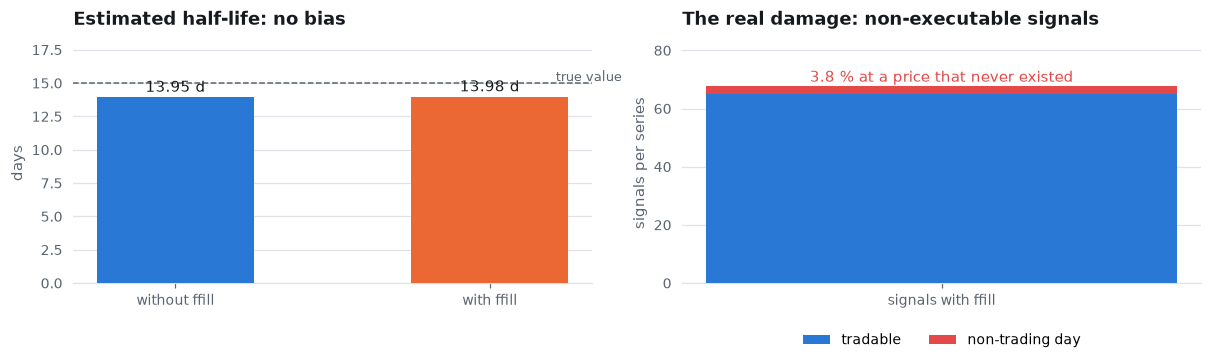

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
a = axes[0]
a.bar(["without ffill", "with ffill"], [r.hl_true.mean(), r.hl_ff.mean()],
      color=[BLUE, ORANGE], width=.5, zorder=3)
a.axhline(15, color=MUTED, ls="--", lw=1)
a.text(1.42, 15.15, "true value", fontsize=8.5, color=MUTED, ha="right")
a.set_title("Estimated half-life: no bias"); a.set_ylabel("days"); a.set_ylim(0, 18)
for i, v in enumerate([r.hl_true.mean(), r.hl_ff.mean()]):
    a.text(i, v + .4, f"{v:.2f} d", ha="center", fontsize=9.5, color=INK)

a = axes[1]
tradable = r.n_f.mean() - r.stale.mean()
a.bar(["signals with ffill"], [tradable], color=BLUE, width=.4, zorder=3, label="tradable")
a.bar(["signals with ffill"], [r.stale.mean()], bottom=[tradable], color=RED, width=.4,
      zorder=3, label="non-trading day")
a.set_title("The real damage: non-executable signals")
a.set_ylabel("signals per series")
a.text(0, r.n_f.mean() + 1.6, f"{100*r.frac_stale.mean():.1f} % at a price that never existed",
       ha="center", fontsize=9.5, color=RED)
a.set_ylim(0, r.n_f.mean() * 1.22); a.legend(loc="lower center", ncol=2, bbox_to_anchor=(.5, -.32))
plt.tight_layout(); plt.show()

### The conclusion, correctly restated

Forward-fill does **not** corrupt the spread's statistics — it corrupts **execution**. About
**4 % of entry signals land on a day the name did not trade**. The backtest then opens a position
at a price that never existed and books P&L on an impossible trade. This is an execution leak, of
the same family as trading at the same day's close on which the signal was computed (the subject
of Phase 6).

> **What to take away for interviews.** If you advance the "manufactured mean reversion" argument
> to someone who has run the simulation, you lose credibility on everything else. Being able to
> say *"I believed it, I tested it, it was false, here is what is true"* is worth more than any
> memorised justification.

**Decision: no forward-fill.** NaNs stay NaNs and are handled explicitly, pair by pair, at test
time.

---
## 6. Why total-return prices, and not raw prices

Three price series exist for the same stock: the **raw price** (what shows on screen), the
**split-adjusted** price, and the **total-return** price (splits *and* dividends reinvested).
We chose total-return, and the reasoning is specific to utilities.

These companies pay 3 to 4 % dividend yield per year, and crucially that yield is **widely
dispersed** across names. The raw price separates from the total-return price by a factor growing
with time:

$$\log P^{\text{raw}}(t) \approx \log P^{\text{TR}}(t) - \delta\, t$$

A spread computed on raw prices therefore carries a term $-(\delta_A - \beta\,\delta_B)\,t$:
**a deterministic linear drift** with no economic content.

Let us start by measuring the dispersion of dividend yields on the actual universe.

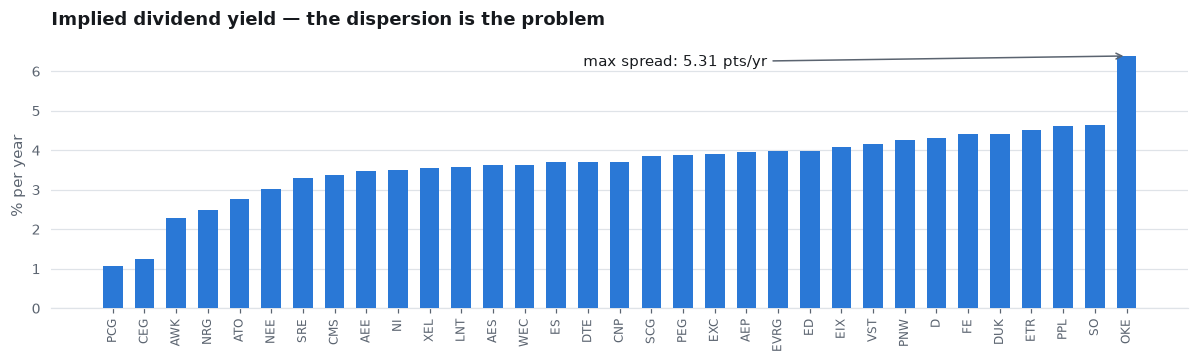

min 1.07 % (PCG)   max 6.39 % (OKE)


In [11]:
import yfinance as yf
raw_path = C.DATA_PROC / "prices_raw_all.parquet"
tk = sorted(trad.columns[trad.any()])
if raw_path.exists():
    raw = pd.read_parquet(raw_path)
else:
    raw = yf.download(tk, start=C.START, end=C.END, auto_adjust=False, progress=False)["Close"]
    raw.to_parquet(raw_path)

# implied dividend yield = annualised gap between the total-return and raw series
yld = {}
for t in tk:
    a, b = close[t].dropna(), raw[t].dropna()
    i = a.index.intersection(b.index)
    if len(i) < 500:
        continue
    yrs = (i[-1] - i[0]).days / 365.25
    yld[t] = (a[i[-1]] / a[i[0]]) ** (1/yrs) - (b[i[-1]] / b[i[0]]) ** (1/yrs)
yld = pd.Series(yld).sort_values()

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(range(len(yld)), 100 * yld.values, color=BLUE, width=.62, zorder=3)
ax.set_xticks(range(len(yld))); ax.set_xticklabels(yld.index, rotation=90, fontsize=8)
ax.set_ylabel("% per year")
ax.set_title("Implied dividend yield — the dispersion is the problem")
ax.annotate(f"max spread: {100*(yld.max()-yld.min()):.2f} pts/yr",
            xy=(len(yld)-1, 100*yld.max()), xytext=(len(yld)*.45, 100*yld.max()*.96),
            fontsize=9.5, color=INK, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
plt.tight_layout(); plt.show()
print(f"min {100*yld.min():.2f} % ({yld.index[0]})   max {100*yld.max():.2f} % ({yld.index[-1]})")

The range runs from **1.07 % (PCG) to 6.39 % (OKE)** — **5.3 points per year** between two names
in the *same sector*. Two details are worth noting: PCG sits at the bottom because PG&E
**suspended its dividend** during the bankruptcy (2019-2022), and OKE sits at the top because
ONEOK is a high-distribution *midstream* company — which also explains its GICS reclassification
from *Utilities* to *Energy* in early 2014.

Over a three-year selection window, a 2-point gap already injects ~6 % of drift into the spread —
comparable to the amplitude of the spread itself.

### The experiment: what does the choice of series change in pair selection?

We test all 465 pairs on a representative in-sample window (2016-2018), once on total-return
prices and once on raw prices, and compare **the resulting selections**.

In [12]:
import itertools
from statsmodels.tsa.stattools import adfuller as adf

def spread_of(src, a, b, idx):
    la, lb = np.log(src[a].loc[idx]), np.log(src[b].loc[idx])
    beta, alpha = np.polyfit(lb, la, 1)
    return la - beta * lb - alpha

# Engle-Granger: OLS of log A on log B, then ADF on the residual
def eg_pvalue(pa, pb, idx):
    la, lb = np.log(pa.loc[idx]), np.log(pb.loc[idx])
    beta, alpha = np.polyfit(lb, la, 1)
    return adf((la - beta * lb - alpha).values, maxlag=1)[1], beta, alpha

win = close.index[(close.index >= "2016-01-01") & (close.index <= "2018-12-31")]
rows = []
for a, b in itertools.combinations([t for t in tk if t in yld.index], 2):
    idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
    idx = idx.intersection(raw[a].dropna().index).intersection(raw[b].dropna().index)
    if len(idx) < 600:
        continue
    d = spread_of(raw, a, b, idx) - spread_of(close, a, b, idx)
    rows.append((a, b, eg_pvalue(close[a], close[b], idx)[0],
                       eg_pvalue(raw[a],   raw[b],   idx)[0],
                 abs(yld[a] - yld[b]), d.iloc[-1] - d.iloc[0]))
scan = pd.DataFrame(rows, columns=["A", "B", "p_TR", "p_raw", "gap_yield", "drift"])

sel_tr  = scan.p_TR  < .05
sel_raw = scan.p_raw < .05
lost    = scan[sel_tr & ~sel_raw]
created = scan[~sel_tr & sel_raw]

# A disagreement may be nothing but p-value noise near the threshold.
# So we isolate DECISIVE flips: p goes from > 0.15 to < 0.05 (or the reverse).
flip_created = int(((scan.p_TR > .15) & (scan.p_raw < .05)).sum())
flip_lost    = int(((scan.p_raw > .15) & (scan.p_TR < .05)).sum())

print(f"pairs tested on 2016-2018 : {len(scan)}")
print(f"  significant at 5 % on TOTAL-RETURN : {sel_tr.sum()}")
print(f"  significant at 5 % on RAW PRICES   : {sel_raw.sum()}")
print(f"\n  disagreement between the two selections : {len(lost)+len(created)} pairs "
      f"({100*(len(lost)+len(created))/len(scan):.1f} %)")
print(f"     of which true pairs LOST    : {len(lost)}")
print(f"     of which false pairs CREATED: {len(created)}")
print(f"\n  BUT much of it is p-value noise near the threshold:")
for name, d in [("lost", lost), ("created", created)]:
    marg = int(((d.p_TR.between(.03, .08)) | (d.p_raw.between(.03, .08))).sum())
    print(f"     {name:8s} : {marg}/{len(d)} marginal ({100*marg/len(d):.0f} %)")
print(f"\n  DECISIVE FLIPS (p > 0.15 one side, < 0.05 the other):")
print(f"     pairs MANUFACTURED by raw prices : {flip_created}")
print(f"     pairs DESTROYED    by raw prices : {flip_lost}")
print(f"\n  correlation |dividend drift| vs |p-value gap| : "
      f"{scan.drift.abs().corr((scan.p_raw - scan.p_TR).abs()):.3f}")

pairs tested on 2016-2018 : 465
  significant at 5 % on TOTAL-RETURN : 112
  significant at 5 % on RAW PRICES   : 137

  disagreement between the two selections : 51 pairs (11.0 %)
     of which true pairs LOST    : 13
     of which false pairs CREATED: 38

  BUT much of it is p-value noise near the threshold:
     lost     : 11/13 marginal (85 %)
     created  : 26/38 marginal (68 %)

  DECISIVE FLIPS (p > 0.15 one side, < 0.05 the other):
     pairs MANUFACTURED by raw prices : 16
     pairs DESTROYED    by raw prices : 1

  correlation |dividend drift| vs |p-value gap| : 0.285


This result needs to be read carefully, and it is the second place in this notebook where the
initial intuition does not survive the test.

**What we wanted to conclude:** "raw prices manufacture 38 false pairs and destroy 13".
**What the data actually licenses** is more nuanced: 85 % of the lost pairs and 68 % of the
created ones have a p-value in $[0.03,\,0.08]$. These are *marginal* cases: they flip because a
p-value near the threshold is noisy, not because dividend drift changed anything substantial.
Counting them as selection errors would be dishonest.

**What does survive the test is the asymmetry of decisive flips** — those where the p-value goes
from above 0.15 to below 0.05:

| | Decisive flips |
|---|---|
| Pairs **manufactured** by raw prices | **16** |
| Pairs **destroyed** by raw prices | **1** |

Sixteen pairs with no equilibrium relation on economically correct prices become decisively
"significant" once raw prices are used. Only one flips the other way. The correlation between
drift magnitude and p-value gap is **0.29** — positive, so the mechanism is real, but partial:
drift explains part of the phenomenon, not all of it.

**The mechanism, for the decisive cases.** Two names whose total-return prices diverge
economically are not cointegrated. If the one rising faster also pays the larger dividend, then on
raw prices the dividend drift **cancels** the divergence — and the spread becomes artificially
flat, hence "stationary" as far as the test is concerned. You would select a pair with no
equilibrium relation, on the basis of a fortuitous accounting offset.

Let us look at one decisive case in each direction, then isolate the drift term itself.

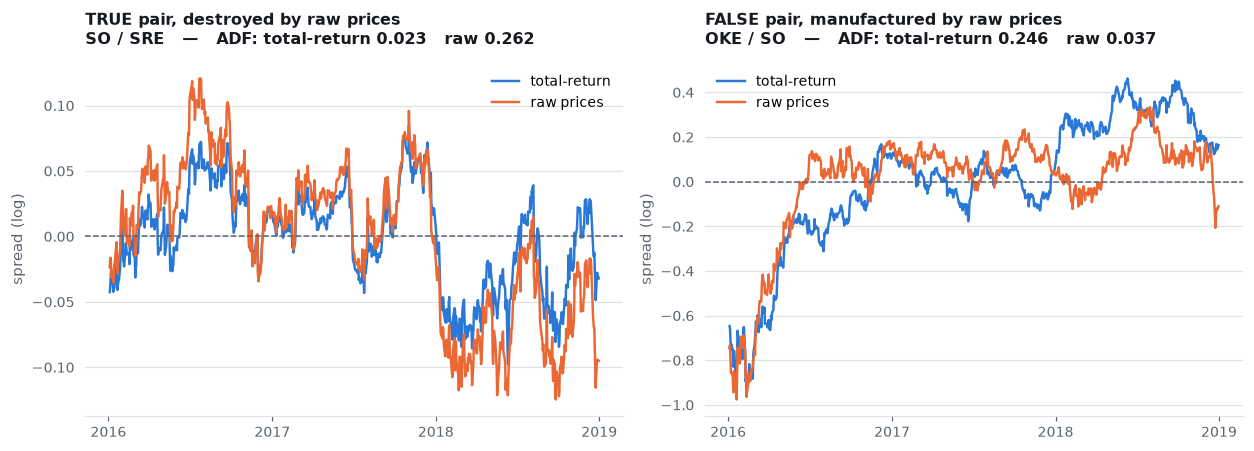

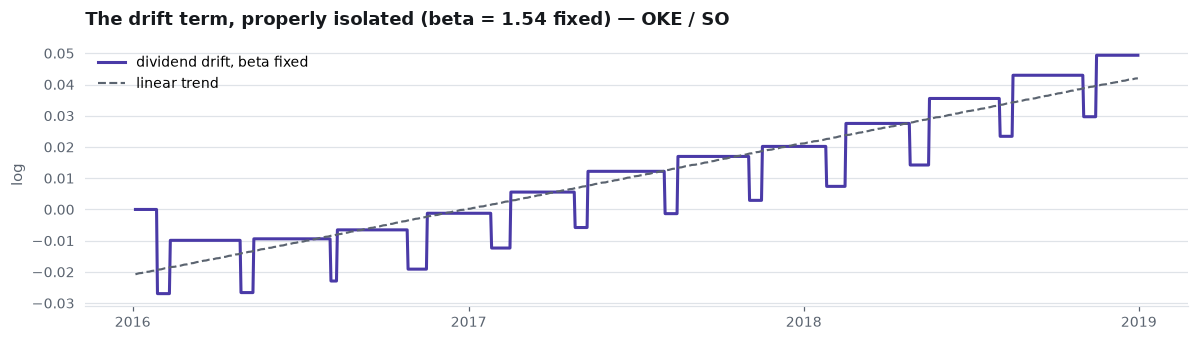

total drift over the window : +0.0494 in log (+5.06 %)
R2 of the linear fit        : 0.8571   -> the drift is indeed deterministic and linear in t


In [13]:
# We illustrate DECISIVE flips, not marginal cases.
flip_c = scan[(scan.p_TR > .15) & (scan.p_raw < .05)].assign(ad=lambda d: d.drift.abs())
best_fake = flip_c.sort_values("ad", ascending=False).iloc[0]
best_lost = scan[(scan.p_raw > .15) & (scan.p_TR < .05)].iloc[0]

import matplotlib.dates as mdates
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, row, title in zip(axes, [best_lost, best_fake],
                          ["TRUE pair, destroyed by raw prices",
                           "FALSE pair, manufactured by raw prices"]):
    a, b = row.A, row.B
    idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
    idx = idx.intersection(raw[a].dropna().index).intersection(raw[b].dropna().index)
    for src, col, lab in [(close, BLUE, "total-return"), (raw, ORANGE, "raw prices")]:
        ax.plot(idx, spread_of(src, a, b, idx).values, color=col, lw=1.6, label=lab)
    ax.axhline(0, color=MUTED, lw=1, ls="--")
    ax.set_title(f"{title}\n{a} / {b}   —   ADF: total-return {row.p_TR:.3f}   "
                 f"raw {row.p_raw:.3f}", fontsize=10.5)
    ax.set_ylabel("spread (log)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(loc="best")
plt.tight_layout(); plt.show()

# ISOLATING the drift term. Careful: simply computing
#     spread(raw) - spread(total-return)
# does NOT isolate it, because beta is re-estimated separately on each series and
# the difference between the two betas introduces a dominant stochastic term.
# We must FIX beta (the total-return one) and apply it to both series.
a, b = best_fake.A, best_fake.B
idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
idx = idx.intersection(raw[a].dropna().index).intersection(raw[b].dropna().index)

beta, _ = np.polyfit(np.log(close[b].loc[idx]), np.log(close[a].loc[idx]), 1)
drift = ((np.log(raw[a].loc[idx]) - np.log(close[a].loc[idx]))
         - beta * (np.log(raw[b].loc[idx]) - np.log(close[b].loc[idx])))
drift = drift - drift.iloc[0]

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(idx, drift.values, color=VIOLET, lw=2, label="dividend drift, beta fixed")
t = np.arange(len(idx))
fit = np.polyfit(t, drift.values, 1)
ax.plot(idx, np.polyval(fit, t), color=MUTED, lw=1.4, ls="--", label="linear trend")
ax.set_title(f"The drift term, properly isolated (beta = {beta:.2f} fixed) — {a} / {b}")
ax.set_ylabel("log"); ax.legend(loc="best")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

r2 = np.corrcoef(np.polyval(fit, t), drift.values)[0, 1] ** 2
print(f"total drift over the window : {drift.iloc[-1]:+.4f} in log "
      f"({100*(np.exp(drift.iloc[-1])-1):+.2f} %)")
print(f"R2 of the linear fit        : {r2:.4f}   "
      f"-> the drift is indeed deterministic and linear in t")

On the left, the total-return spread oscillates around zero — an equilibrium relation. The raw
spread breaks away from 2018: the drift destroyed stationarity, and the test rejects a genuinely
cointegrated pair.

On the right, the reverse, and the more instructive case. The total-return spread (blue) rises
sharply in 2018, up to +0.4: the two names diverge, there is no equilibrium relation. The raw
spread (orange) stays much flatter — the dividend drift **offsets** the economic divergence. The
test wrongly concludes cointegration.

The third chart isolates the drift term. A trap lurks there, and it was worth fixing: simply
computing `spread(raw) − spread(total-return)` **isolates nothing**, because beta is re-estimated
separately on each series and the gap between the two betas introduces a stochastic term that
dominates everything. By **fixing** beta, we get what theory predicts: a linear trend, with an
$R^2$ of **0.86**.

And the **staircase** shape confirms the mechanism. A dividend is not paid continuously: it goes
ex four times a year, on fixed dates. Each step is one ex-dividend date on one of the two legs.
The drift is not a modelling abstraction — you literally watch each payment accumulate in the
spread.

> **The conclusion to state in an interview.** The two price series produce selections that differ
> on 11 % of pairs. Most of that disagreement is p-value noise near the threshold — saying so is
> more honest than announcing "38 false pairs". But the asymmetry of decisive flips, **16 against
> 1**, is robust: raw prices manufacture apparent cointegration far more often than they destroy
> it. The choice of price series is not a data-preparation detail — **it is a decision that
> changes the selection itself.**

Total-return is also the right **economic** object: a long/short position genuinely collects the
dividend on the long leg and pays it on the short leg.

> **The residual leak you must be able to name.** Adjusted prices are *retro*-adjusted: every new
> dividend retroactively modifies the whole historical series. The 2018 series as I download it in
> 2026 is not the one a trader observed in 2018. The effect is second-order here (both legs are
> adjusted in the same direction, the position is long/short) but it exists — and naming it
> spontaneously separates someone who has thought about it from someone who followed a tutorial.

---
## 7. Residual survivorship: quantified, and above all **signed**

Point-in-time fixes the composition. It does not fix the unavailability of prices for companies
that disappeared. Let us see what remains.

excluded tickers (5) : ['GAS', 'NU', 'POM', 'TE', 'TEG']
membership slots : 732 raw -> 708 kept (3.3 % lost)
last snapshot with losses : 2016-07


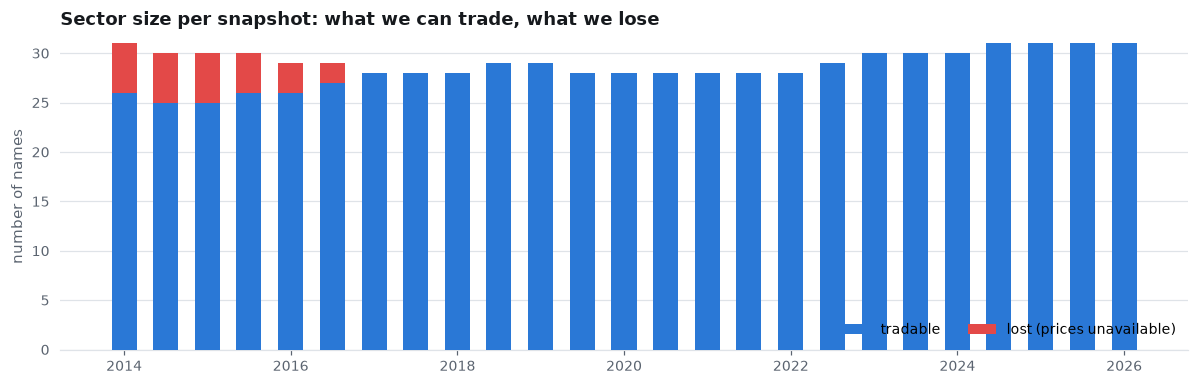

In [14]:
missing = sorted(set(memb.columns[memb.any()]) - set(trad.columns[trad.any()]))
per = pd.DataFrame({"raw": memb.sum(axis=1), "tradable": trad.sum(axis=1)})
per["lost"] = per.raw - per.tradable
slots_all, slots_kept = int(memb.values.sum()), int(trad.values.sum())

print(f"excluded tickers ({len(missing)}) : {missing}")
print(f"membership slots : {slots_all} raw -> {slots_kept} kept "
      f"({100*(slots_all-slots_kept)/slots_all:.1f} % lost)")
print(f"last snapshot with losses : {per[per.lost>0].index[-1]:%Y-%m}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(per.index, per.tradable, width=110, color=BLUE, zorder=3, label="tradable")
ax.bar(per.index, per.lost, bottom=per.tradable, width=110, color=RED, zorder=3,
       label="lost (prices unavailable)")
ax.set_title("Sector size per snapshot: what we can trade, what we lose")
ax.set_ylabel("number of names")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

Losses are **entirely concentrated in 2014-2016** and **zero from January 2017 onward**.

### The direction of the bias — the most important point

All five lost names left the index **by acquisition**, none by bankruptcy:

| Ticker | What happened |
|---|---|
| `GAS` | AGL Resources, acquired by Southern Company (2016). No data: outright loss. |
| `NU`  | Northeast Utilities, **renamed Eversource (ES)** in 2015. Only an apparent loss: the `ES` series goes back to 2014 and carries the history. |
| `POM` | Pepco Holdings, acquired by Exelon (2016). |
| `TE`  | TECO Energy, acquired by Emera (2016). |
| `TEG` | Integrys Energy, acquired by WEC (2015). |

A takeover is precisely the event that breaks cointegration most brutally: the target's price
jumps to the offer price then **freezes**, permanently decorrelated from its sector. A short
position on the target at announcement takes an instant loss that **never** reverts.

> **State it exactly like this:** excluding these names removes extreme, irreversible loss
> scenarios from the sample. **The residual bias therefore overstates performance.** This is the
> most dangerous case, because a favourable bias never announces itself: you have no reason to go
> looking for it, since the results look good.
>
> Practical consequence: the first fold (selection 2014-2016) is the most exposed. Honesty means
> reporting its result **separately** rather than aggregating it with the others.

### Two grey areas, acknowledged

- **EVRG** — Evergy was formed in 2018 from the Westar / Great Plains merger. Served history goes
  back to 2014: those are the predecessor's prices. Defensible, but worth knowing.
- **SCG** — SCANA shows an overlap of 0.69: served history starts in July 2015 while the company
  was a member from 2014. Truncated history, consistent identity. Kept.

---
## 8. Where we stand, and the figure that opens Phase 3

In [15]:
n_max = int(trad.sum(axis=1).max()); n_min = int(trad.sum(axis=1).min())
pairs = n_max * (n_max - 1) // 2
print(f"tradable universe      : {int(trad.any().sum())} tickers")
print(f"sector size by date    : {n_min} to {n_max} names")
print(f"maximum testable pairs : {pairs}")
print(f"\nunder H0 -- no pair is truly cointegrated -- a 5 % test would still")
print(f"declare ~{0.05*pairs:.0f} SIGNIFICANT, by pure chance.")

tradable universe      : 33 tickers
sector size by date    : 25 to 31 names
maximum testable pairs : 465

under H0 -- no pair is truly cointegrated -- a 5 % test would still
declare ~23 SIGNIFICANT, by pure chance.


**That is the figure that opens Phase 3.** If the screener finds 30 "significant" pairs when ~23
are expected by pure chance, it has found almost nothing. That is the whole point of honest
selection: compare what you find to what chance would produce, then correct (Bonferroni,
Benjamini-Hochberg) and **freeze the selection before the trading window**.

### The liquidity filter: why it is not in this notebook

The plan calls for a universe of **liquid** stocks. No filter was applied — deliberately.
Filtering now would mean computing median volume over the **whole** 2014-2026 period and keeping
names above a threshold. You would then be using, to decide what to trade in 2015, the information
"this name will still be liquid in 2025" — information correlated with the firm's survival and
success. **That is survivorship bias dressed up as a technical criterion.**

The filter will be recomputed **at each fold, on the in-sample window only**, exactly like pair
selection. It therefore arrives in Phase 3.

### Guardrails summary

| Guardrail | Against what | Where |
|---|---|---|
| Point-in-time membership | Survivorship in the composition | `src/universe.py` |
| Blocking identity check | Ticker recycling | `validate_identity` |
| Total-return prices | Dividend drift in the spread | `src/data.py` |
| No forward-fill | Signals on non-trading days | `src/data.py` |
| "Live names" denominator | Deleting valid sessions | `_clean` |
| Disk cache of revisions | Non-reproducible universe | `data/raw/wiki/` |
| Loud failure on failed request | Silently truncated universe | `_get` |
| Dated universe decision | Sector-level data snooping | `docs/01_universe_decision.md` |
| Deferred liquidity filter | Survivorship disguised as a technical criterion | Phase 3 |

---

**Next — Phase 2:** the statistical building blocks. Engle-Granger, ADF, half-life via an
Ornstein-Uhlenbeck fit, and the z-score on a **causal rolling window** (a z-score computed on the
full-period mean is the single most common leak in pairs trading).